In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_raw = pd.read_csv('../data/raw/PRSA_data_2010.1.1-2014.12.31.csv')

In [60]:
def data_prep(df_raw: pd.DataFrame) -> pd.DataFrame:
	df_local = df_raw.drop(columns = 'No').copy()	
	
	cols = [x.lower() for x in df_local.columns]
	df_local.columns = cols
	
	# astype str in the following features
	df_local['year'] = df_local.year.astype(str)
	df_local['month'] = df_local.month.astype(str)
	df_local['day'] = df_local.day.astype(str)
	df_local['hour'] = df_local.hour.astype(str)

	return df_local.copy()

In [61]:
df = data_prep(df_raw)

In [44]:
df.describe()

,pm2.5,dewp,temp,pres,iws,is,ir
count,41757.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000
mean,98.613215,1.817246,12.448521,1016.447654,23.889140,0.052734,0.194916
std,92.050387,14.433440,12.198613,10.268698,50.010635,0.760375,1.415867
min,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000
25%,29.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000
50%,72.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000
75%,137.000000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000
max,994.000000,28.000000,42.000000,1046.000000,585.600000,27.000000,36.000000


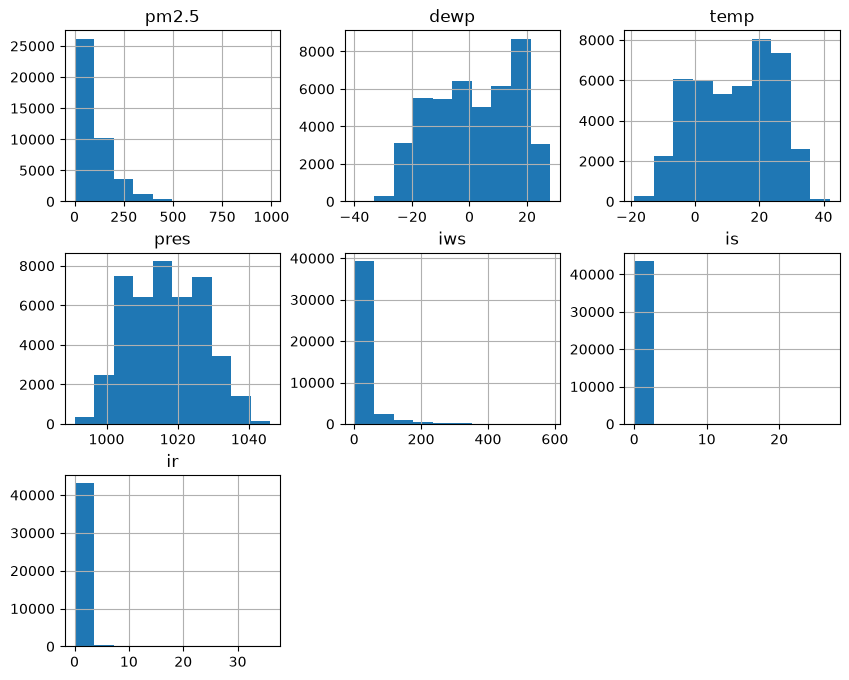

In [45]:
df.hist(figsize = (10, 8))
plt.show()

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    43824 non-null  int64  
 1   month   43824 non-null  int64  
 2   day     43824 non-null  int64  
 3   hour    43824 non-null  int64  
 4   pm2.5   41757 non-null  float64
 5   dewp    43824 non-null  int64  
 6   temp    43824 non-null  float64
 7   pres    43824 non-null  float64
 8   cbwd    43824 non-null  str    
 9   iws     43824 non-null  float64
 10  is      43824 non-null  int64  
 11  ir      43824 non-null  int64  
dtypes: float64(4), int64(7), str(1)
memory usage: 4.0 MB


In [62]:
df['month'] = df.month.str.pad(side = 'left', width = 2, fillchar = '0')
df['day'] = df.day.str.pad(side = 'left', width = 2, fillchar = '0')
df['date'] = df.year + '-' + df.month + '-' + df.day
df['period'] = df.year + df.month 